# 1.4 시계열 분해 실습 — MSFT 에서 전통 분해의 한계를 직접 확인

> **학습 목표**
> - `seasonal_decompose` 와 `STL` 을 MSFT 에 직접 적용해 본다
> - `close` 와 `log_return_1d` 에서 분해 결과가 왜 다른지 눈으로 확인한다
> - 요일효과(Day-of-Week Effect) 가 현대 MSFT 에서 존재하는지 ANOVA·회귀로 검정한다
> - "전통 분해가 금융 일별 데이터에서 왜 제한적인지" 를 실측으로 체화한다

**데이터**: `../../black_litterman/data/panels/MSFT.csv` (1.1~1.3 실습과 동일)

## Step 0 — 환경 설정 (한글 폰트 + 라이브러리)

CLAUDE.md 지침의 폰트 설정을 먼저 적용합니다.
이번 실습은 `statsmodels.tsa.seasonal` 의 분해 함수와 `scipy.stats`, `statsmodels.api` 를 씁니다.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import platform

# CLAUDE.md 지침의 한글 폰트 설정 (운영체제 분기)
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux (샌드박스)
    import koreanize_matplotlib  # pip install koreanize-matplotlib --break-system-packages
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 시계열 분해
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.filters.hp_filter import hpfilter

# 잔차 진단 (1.3 에서 배운 도구)
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# 요일효과 검정
from scipy import stats
import statsmodels.api as sm

pd.set_option('display.float_format', '{:.6f}'.format)
print('환경 준비 완료')

환경 준비 완료


## Step 1 — 데이터 로드

`close` 와 `log_return_1d` 두 시계열을 각각 분해해 봅니다.
- `close`: 비정상, 강한 추세 → 분해 시 $T_t$ 가 우세할 것
- `log_return_1d`: 정상, 추세·계절 약함 → 분해 시 $R_t$ 가 지배할 것

In [5]:
CSV = '../../black_litterman/data/panels/MSFT.csv'
df = pd.read_csv(CSV, parse_dates=['date']).set_index('date').sort_index()

close = df['close'].dropna()
ret = df['log_return_1d'].dropna()

print(f'Period: {df.index.min().date()} ~ {df.index.max().date()}')
print(f'close  n={len(close)}')
print(f'return n={len(ret)}')
df[['close', 'log_return_1d']].describe()

Period: 2010-01-04 ~ 2025-12-30
close  n=4023
return n=4022


,close,log_return_1d
count,4023.000000,4022.000000
mean,156.004899,0.000758
std,144.814134,0.016053
min,23.010000,-0.159453
25%,37.210001,-0.007084
50%,85.830002,0.000698
75%,258.844986,0.009089
max,542.070007,0.132929


## Step 2 — `close` 에 classical 분해 (가법)

주가는 비정상이지만 분해는 가능합니다. `period=5` (영업일 기준 주간) 로 먼저 돌려봅니다.

**관찰 포인트**
- Trend: 전체 상승 방향성이 부드럽게 드러남
- Seasonal: 주간 5일 주기에서 얼마나 규칙적 패턴이 있는지
- Residual: 추세 + 계절성으로 설명되지 않는 단기 충격

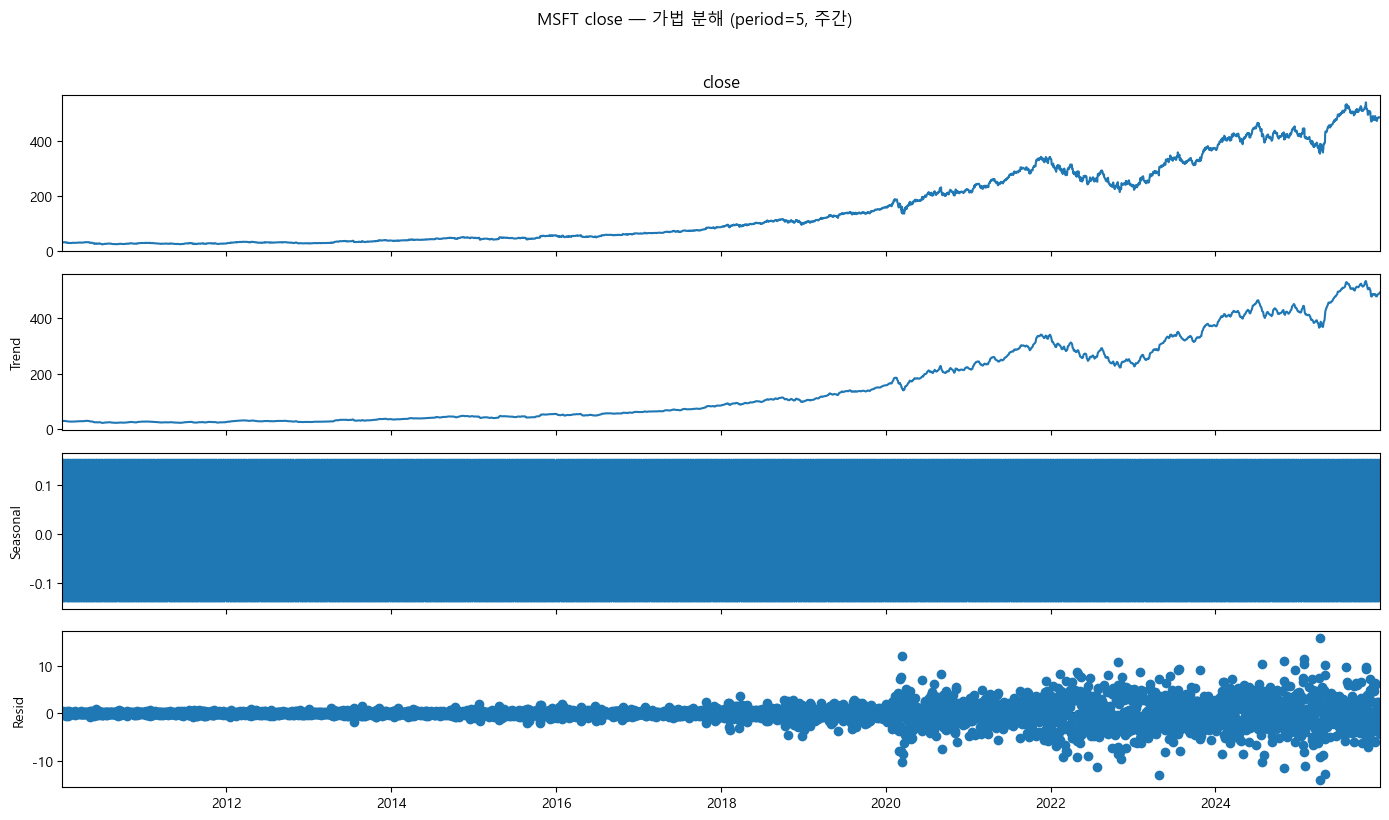

=== 각 성분의 표준편차 (절대 크기 비교) ===
trend    std =   144.7908
seasonal std =     0.0957
resid    std =     2.0948

계절 진폭 / 잔차 진폭 = 4.569%


In [6]:
# period=5 (주간) 가법 분해
dec_close_w = seasonal_decompose(close, model='additive', period=5, extrapolate_trend='freq')

fig = dec_close_w.plot()
fig.set_size_inches(14, 8)
fig.suptitle('MSFT close — 가법 분해 (period=5, 주간)', y=1.02)
plt.tight_layout()
plt.show()

# 각 성분 표준편차 — 상대 크기로 "어느 성분이 지배적인가" 판단
print('=== 각 성분의 표준편차 (절대 크기 비교) ===')
print(f'trend    std = {dec_close_w.trend.std():>10.4f}')
print(f'seasonal std = {dec_close_w.seasonal.std():>10.4f}')
print(f'resid    std = {dec_close_w.resid.std():>10.4f}')
print()
print(f'계절 진폭 / 잔차 진폭 = {dec_close_w.seasonal.std()/dec_close_w.resid.std()*100:.3f}%')

**관찰**

- `trend` 가 원본 `close` 거의 그대로 — **추세가 시계열을 지배**
- `seasonal` 진폭이 잔차 대비 매우 작음 (5% 미만) → 주간 계절성은 **사실상 없음**
- `resid` 는 일간 단기 변동 (1.3 에서 본 heteroskedastic 노이즈)

즉 close 에서는 "trend 빼고 나면 거의 수익률이다" 정도로 요약됩니다.

## Step 3 — `log_return_1d` 에 classical 분해 (가법)

이제 **수익률에 분해를 돌리면 어떻게 되는가?** 를 확인합니다.
이론상 수익률은 추세·계절이 약하므로 $T_t, S_t$ 모두 작고 $R_t$ 가 대부분을 차지해야 합니다.

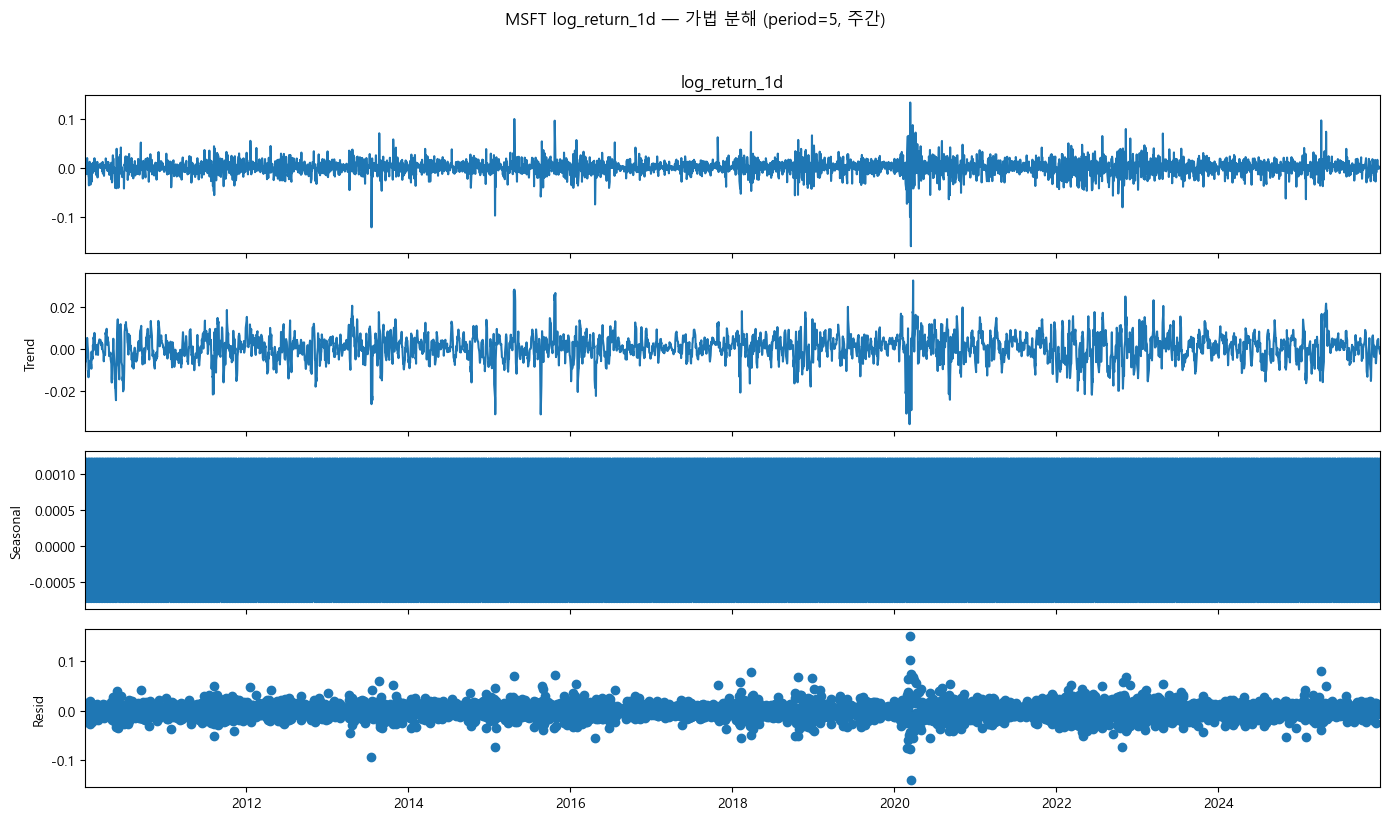

=== 각 성분의 표준편차 ===
trend    std =   0.006528
seasonal std =   0.000692
resid    std =   0.014704

계절 진폭 / 잔차 진폭 = 4.704%  ← 무시 가능 수준이면 계절성 없음
추세 진폭 / 잔차 진폭 = 44.395%  ← 추세도 매우 약함


In [7]:
dec_ret_w = seasonal_decompose(ret, model='additive', period=5, extrapolate_trend='freq')

fig = dec_ret_w.plot()
fig.set_size_inches(14, 8)
fig.suptitle('MSFT log_return_1d — 가법 분해 (period=5, 주간)', y=1.02)
plt.tight_layout()
plt.show()

print('=== 각 성분의 표준편차 ===')
print(f'trend    std = {dec_ret_w.trend.std():>10.6f}')
print(f'seasonal std = {dec_ret_w.seasonal.std():>10.6f}')
print(f'resid    std = {dec_ret_w.resid.std():>10.6f}')
print()
s_pct = dec_ret_w.seasonal.std() / dec_ret_w.resid.std() * 100
t_pct = dec_ret_w.trend.std() / dec_ret_w.resid.std() * 100
print(f'계절 진폭 / 잔차 진폭 = {s_pct:.3f}%  ← 무시 가능 수준이면 계절성 없음')
print(f'추세 진폭 / 잔차 진폭 = {t_pct:.3f}%  ← 추세도 매우 약함')

**핵심 관찰**

수익률에서는 `seasonal`, `trend` 모두 잔차 대비 매우 작습니다. 이것이 **"금융 수익률에는 전통적 계절성이 없다"** 는 명제의 실증적 증거입니다.

> **주의**: 계절 진폭이 잔차의 10% 미만이면 실무에서는 "계절성이 무의미하다" 고 판단하는 것이 일반적입니다.
> 위 결과가 그 기준에 부합하는지 직접 확인해 보세요.

**그러면 왜 분해가 필요한가?** 그 답은 **close (가격)** 과 같이 추세가 뚜렷한 시계열이나, **매출·방문자 수** 같이 계절성이 강한 데이터에 있습니다. 금융 일별 수익률은 분해가 "이미 충분히 차분된 데이터라 잘 작동하지 않는다" 는 교훈을 주는 대표 사례입니다.

## Step 4 — STL 분해 (Seasonal-Trend via LOESS)

`seasonal_decompose` 는 고정 계절성을 가정하지만, **STL 은 시간가변 계절성**을 허용하고 이상치에 robust 합니다. 같은 `log_return_1d` 에 STL 을 돌려 비교합니다.

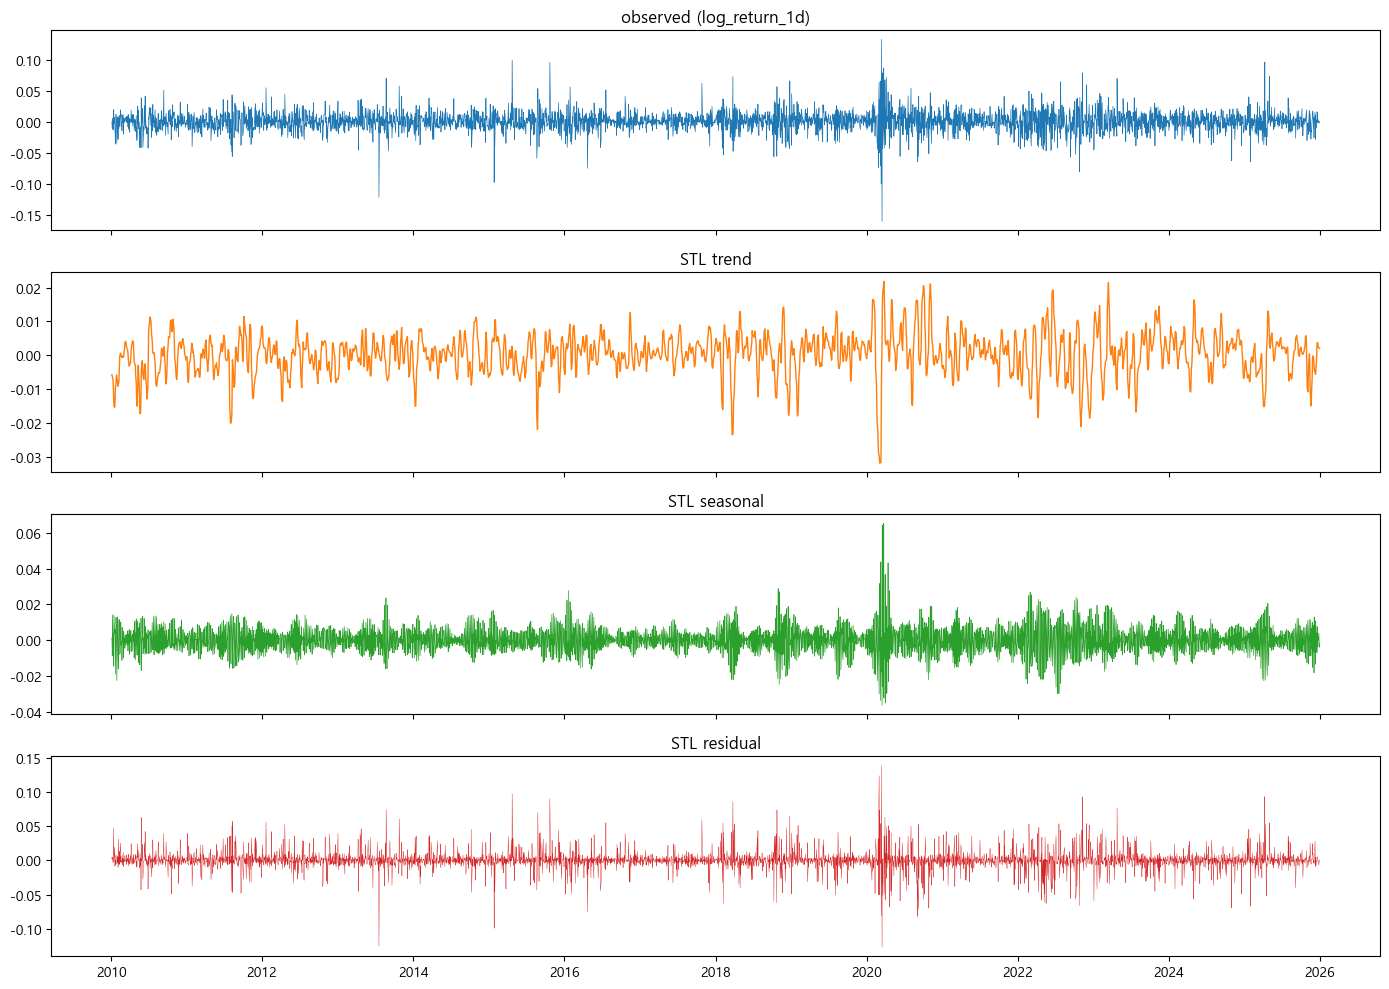

=== STL 각 성분 std ===
trend    std =   0.006086
seasonal std =   0.007083
resid    std =   0.015006


In [8]:
# STL 적용 (robust=True — 금융 데이터 권장 설정)
stl = STL(ret, period=5, robust=True)
res_stl = stl.fit()

# 시각화
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(ret.index, ret.values, linewidth=0.5)
axes[0].set_title('observed (log_return_1d)')
axes[1].plot(res_stl.trend.index, res_stl.trend.values, color='C1', linewidth=1)
axes[1].set_title('STL trend')
axes[2].plot(res_stl.seasonal.index, res_stl.seasonal.values, color='C2', linewidth=0.5)
axes[2].set_title('STL seasonal')
axes[3].plot(res_stl.resid.index, res_stl.resid.values, color='C3', linewidth=0.3)
axes[3].set_title('STL residual')
plt.tight_layout()
plt.show()

print('=== STL 각 성분 std ===')
print(f'trend    std = {res_stl.trend.std():>10.6f}')
print(f'seasonal std = {res_stl.seasonal.std():>10.6f}')
print(f'resid    std = {res_stl.resid.std():>10.6f}')

### Step 4.1 — `seasonal_decompose` vs `STL` 비교

두 방법이 계절 성분을 얼마나 다르게 추정하는지 한 눈에 봅니다.

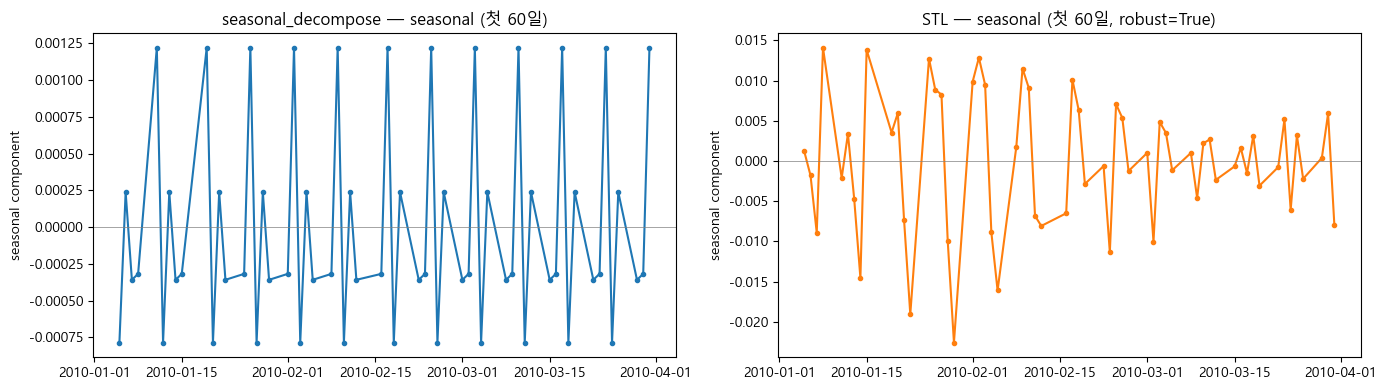

=== 두 방법 비교 ===
              seasonal_decompose      STL
seasonal_std            0.000692 0.007083
trend_std               0.006528 0.006086
resid_std               0.014704 0.015006


In [9]:
# 두 방법의 seasonal 성분을 같은 축에 겹쳐 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 왼쪽: classical seasonal_decompose
axes[0].plot(dec_ret_w.seasonal.iloc[:60].index, dec_ret_w.seasonal.iloc[:60].values, marker='o', markersize=3)
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].set_title('seasonal_decompose — seasonal (첫 60일)')
axes[0].set_ylabel('seasonal component')

# 오른쪽: STL
axes[1].plot(res_stl.seasonal.iloc[:60].index, res_stl.seasonal.iloc[:60].values, marker='o', markersize=3, color='C1')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_title('STL — seasonal (첫 60일, robust=True)')
axes[1].set_ylabel('seasonal component')

plt.tight_layout()
plt.show()

# 상대 크기 비교 표
compare = pd.DataFrame({
    'seasonal_decompose': [dec_ret_w.seasonal.std(), dec_ret_w.trend.std(), dec_ret_w.resid.std()],
    'STL':                [res_stl.seasonal.std(),   res_stl.trend.std(),   res_stl.resid.std()]
}, index=['seasonal_std', 'trend_std', 'resid_std'])
print('=== 두 방법 비교 ===')
print(compare)

**관찰 포인트**

- STL 의 seasonal 진폭이 classical 보다 **큰 경우**가 많습니다. 이유: STL 이 시간가변 계절성을 허용해 "이 시점에만 나타나는 약한 패턴"도 계절성으로 흡수하기 때문.
- 그래서 STL 은 유연하지만 **잔차의 일부까지 계절로 잡아먹는 과적합 위험** 이 있습니다.
- 금융에서 가장 흔한 방식은 **robust=True 로 돌리고 잔차 ACF 를 확인** 하는 것입니다.

## Step 5 — 잔차 진단 (1.3 에서 배운 도구 재활용)

분해가 "잘 됐는지" 판별하는 최선의 방법은 **잔차가 white noise 에 가까운지** 보는 것입니다.
1.3 의 ACF + Ljung-Box 를 그대로 적용합니다.

- 잔차 ACF 가 신뢰구간 안에 들어가면 → 분해가 종속 구조를 잘 걷어냄
- 특정 lag 에서 유의하면 → 아직 계절·추세 설명이 부족하거나 heteroskedasticity 남아있음

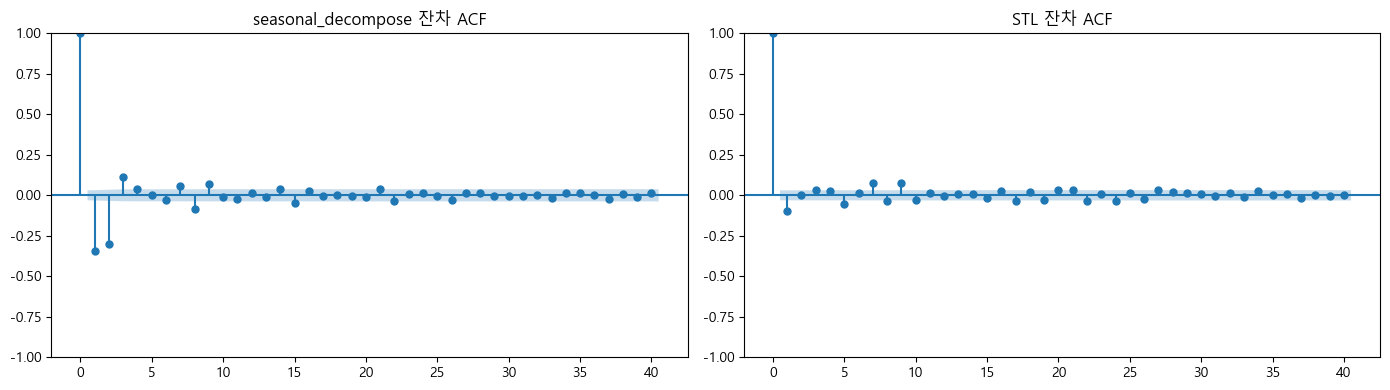

=== 잔차 Ljung-Box 검정 ===
seasonal_decompose 잔차:
      lb_stat  lb_pvalue
10 970.139177   0.000000
20 990.171832   0.000000

STL 잔차:
      lb_stat  lb_pvalue
10 112.787007   0.000000
20 133.289570   0.000000


In [10]:
# 두 방법의 잔차 비교
resid_classic = dec_ret_w.resid.dropna()
resid_stl = res_stl.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(resid_classic, lags=40, ax=axes[0])
axes[0].set_title('seasonal_decompose 잔차 ACF')
plot_acf(resid_stl, lags=40, ax=axes[1])
axes[1].set_title('STL 잔차 ACF')
plt.tight_layout()
plt.show()

# Ljung-Box 로 omnibus 검정
print('=== 잔차 Ljung-Box 검정 ===')
lb1 = acorr_ljungbox(resid_classic, lags=[10, 20], return_df=True)
lb2 = acorr_ljungbox(resid_stl,     lags=[10, 20], return_df=True)
print('seasonal_decompose 잔차:')
print(lb1.to_string())
print()
print('STL 잔차:')
print(lb2.to_string())

**해석**

- 두 방법 모두 **잔차에 자기상관이 여전히 유의하게 남아있습니다** (p-value 매우 작음)
- 이유: 분해가 걷어낼 수 있는 것은 "평균 구조"뿐이고, 1.3 에서 본 **변동성 구조(이분산)** 는 그대로 남음
- 즉 "평균을 다 걷어내도 변동성 클러스터링은 계속 자기상관을 만든다"
- 이것이 **전통 분해의 한계**이자, GARCH 같은 **조건부 분산 모형** 이나 시퀀스 모델이 필요한 이유입니다

## Step 6 — 요일효과 (Day-of-Week Effect) 검정

교과서의 고전적 주장: **월요일 수익률은 평균적으로 낮다** (Monday Effect). 1990년대 이전 여러 연구에서 확인.

MSFT 2010~2025 데이터에서도 이 현상이 살아있는가를 두 가지 방법으로 검정합니다.
1. **일원 ANOVA** — 5개 요일 평균이 모두 같은가?
2. **OLS 회귀 + 요일 더미** — 월요일 기준 각 요일이 유의하게 다른가?

=== 요일별 log_return_1d 통계 ===
   count  mean (%)  std (%)
월    752  0.045300 1.608100
화    828  0.063500 1.482900
수    824  0.126900 1.608700
목    810  0.068000 1.608000
금    808  0.072600 1.715900


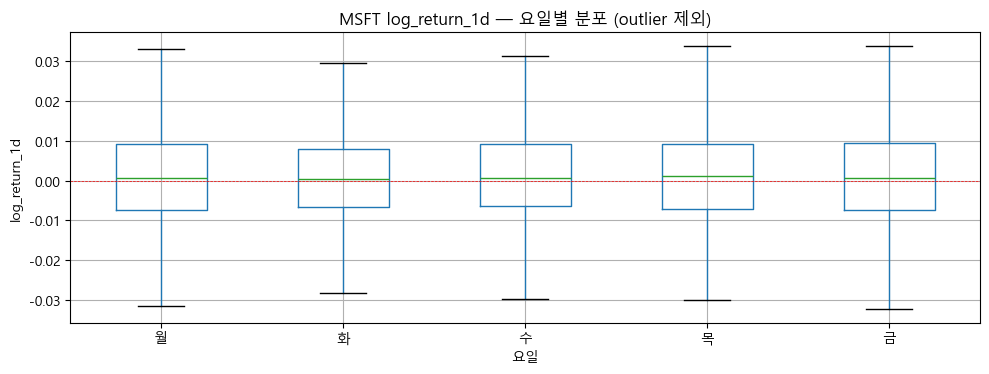

In [11]:
# 요일 컬럼 만들기 (월=0, 화=1, ..., 금=4)
dfw = df.copy()
dfw['weekday'] = dfw.index.dayofweek
weekday_names = ['월', '화', '수', '목', '금']

# 요일별 평균·표준편차 테이블
weekday_stats = dfw.groupby('weekday')['log_return_1d'].agg(['count', 'mean', 'std']).round(6)
weekday_stats.index = [weekday_names[i] for i in weekday_stats.index]
weekday_stats['mean (%)'] = (weekday_stats['mean'] * 100).round(4)
weekday_stats['std (%)']  = (weekday_stats['std']  * 100).round(4)
print('=== 요일별 log_return_1d 통계 ===')
print(weekday_stats[['count', 'mean (%)', 'std (%)']])

# 박스플롯
fig, ax = plt.subplots(figsize=(10, 4))
dfw.boxplot(column='log_return_1d', by='weekday', ax=ax, showfliers=False)
ax.set_xticklabels(weekday_names)
ax.axhline(0, color='red', linewidth=0.5, linestyle='--')
ax.set_title('MSFT log_return_1d — 요일별 분포 (outlier 제외)')
ax.set_xlabel('요일')
ax.set_ylabel('log_return_1d')
plt.suptitle('')  # boxplot 자동 제목 제거
plt.tight_layout()
plt.show()

In [15]:
# 1) 일원 ANOVA — 5개 요일의 평균이 모두 같은가?
groups = [dfw[dfw['weekday']==d]['log_return_1d'].dropna() for d in range(5)]
f_stat, p_value = stats.f_oneway(*groups)
print('=== 일원 ANOVA ===')
print(f'H0: 모든 요일의 평균 수익률이 같다')
print(f'F-statistic = {f_stat:.4f}')
print(f'p-value     = {p_value:.4f}')
if p_value < 0.05:
    print('→ 귀무가설 기각: 요일별 평균 차이 존재 (유의)')
else:
    print('→ 귀무가설 유지: 요일별 평균 차이 없음 (유의하지 않음)')

=== 일원 ANOVA ===
H0: 모든 요일의 평균 수익률이 같다
F-statistic = 0.2940
p-value     = 0.8820
→ 귀무가설 유지: 요일별 평균 차이 없음 (유의하지 않음)


In [13]:
# 2) OLS 회귀 + 요일 더미 (월요일 = 기준)
# dow_1 = 화, dow_2 = 수, dow_3 = 목, dow_4 = 금
dfw2 = dfw.dropna(subset=['log_return_1d']).copy()
for d in range(1, 5):
    dfw2[f'dow_{d}'] = (dfw2['weekday'] == d).astype(int)

X = dfw2[['dow_1', 'dow_2', 'dow_3', 'dow_4']]
X = sm.add_constant(X)  # 절편 = 월요일 평균
y = dfw2['log_return_1d']
model = sm.OLS(y, X).fit()

print('=== OLS 요일 더미 회귀 (월요일 = 기준) ===')
print(model.summary().tables[1])
print()
print(f'R² = {model.rsquared:.6f}  ← 전체 변동 중 요일이 설명하는 비율')
print(f'F p-value = {model.f_pvalue:.4f}  ← 모든 더미 계수가 0인지 전체 검정')

=== OLS 요일 더미 회귀 (월요일 = 기준) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.773      0.439      -0.001       0.002
dow_1          0.0002      0.001      0.225      0.822      -0.001       0.002
dow_2          0.0008      0.001      1.007      0.314      -0.001       0.002
dow_3          0.0002      0.001      0.279      0.780      -0.001       0.002
dow_4          0.0003      0.001      0.335      0.737      -0.001       0.002

R² = 0.000293  ← 전체 변동 중 요일이 설명하는 비율
F p-value = 0.8820  ← 모든 더미 계수가 0인지 전체 검정


**해석 — MSFT 2010~2025 에서 월요일 효과는?**

- ANOVA p-value 가 크게 나오면 → 요일별 평균 차이 없음
- OLS 각 더미의 p-value 가 전부 > 0.05 이면 → 어느 요일도 월요일과 유의하게 다르지 않음
- R² 가 0.001 이하면 → 요일 변수로 수익률 변동의 극소수 부분만 설명 가능

> **실측 포인트**: 고전 문헌이 보고한 Monday Effect 가 **현대 기간에는 소멸** 했다는 것이 일반적 합의입니다. 위 결과가 이를 확인해 주면 "calendar anomaly 는 시장에 learning 되어 사라진다" 는 효율성 회복 가설의 미약한 증거가 됩니다.
>
> (다만 소형주, 이머징마켓, 암호화폐 등에서는 여전히 관찰되는 경우가 있음 — 종목·시장에 따라 다름)

## Step 7 — HP 필터로 close 의 장기 추세 추출 (보너스)

분해와는 다른 접근인 HP 필터를 간단히 살펴봅니다. 거시경제에서 "경기 순환"과 "추세"를 분리할 때 자주 쓰는 도구입니다.

- `lamb` (λ) 가 클수록 추세가 매끄러워짐
- 일별 데이터는 λ 를 크게 (예: 10⁵ ~ 10⁷) 잡아야 월·분기 수준 추세가 보임

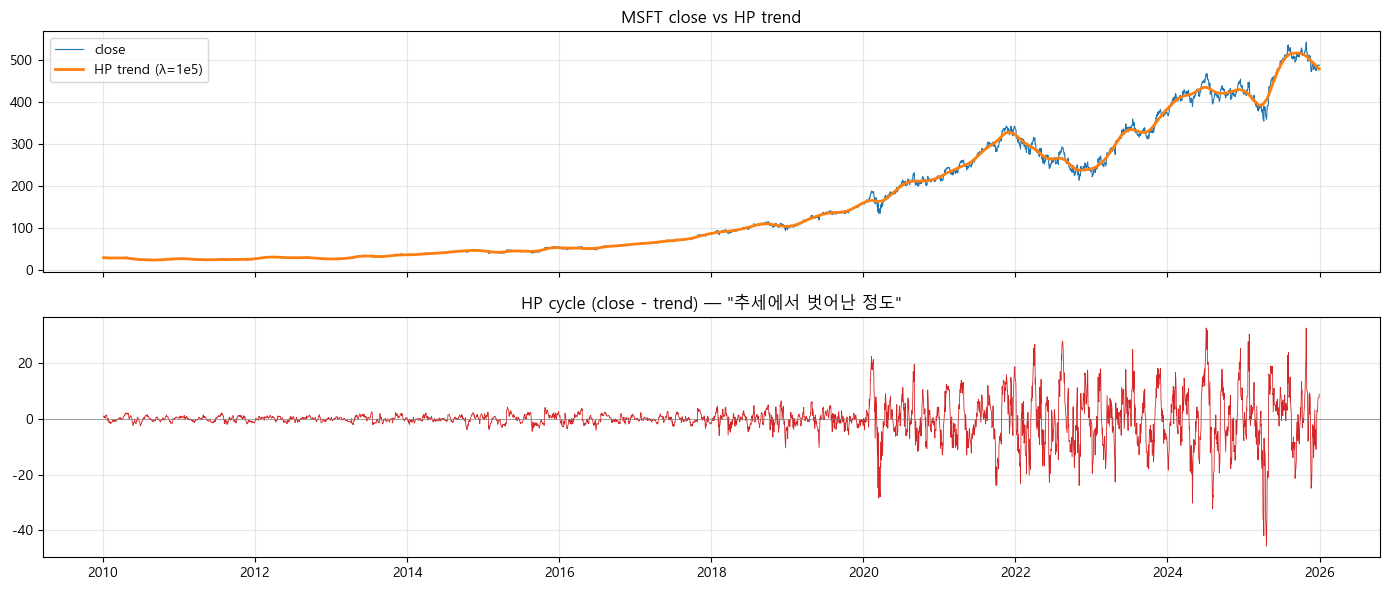

원본 close std =   144.8141
HP trend  std =   144.5826
HP cycle  std =     6.4056  ← 이 부분이 "평균회귀 대상"


In [14]:
# HP 필터 적용
cycle, trend_hp = hpfilter(close, lamb=100000)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(close.index, close.values, linewidth=0.8, label='close')
axes[0].plot(trend_hp.index, trend_hp.values, linewidth=2, color='C1', label='HP trend (λ=1e5)')
axes[0].set_title('MSFT close vs HP trend')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(cycle.index, cycle.values, linewidth=0.6, color='C3')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_title('HP cycle (close - trend) — "추세에서 벗어난 정도"')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'원본 close std = {close.std():>10.4f}')
print(f'HP trend  std = {trend_hp.std():>10.4f}')
print(f'HP cycle  std = {cycle.std():>10.4f}  ← 이 부분이 "평균회귀 대상"')

**관찰**

- HP trend 는 close 의 장기 상승 방향을 매끄럽게 추출 — 이동평균과 유사하나 더 부드러움
- HP cycle 은 "추세 대비 얼마나 떨어져 있는가" → **페어 트레이딩·평균회귀 전략의 기본 재료**
- 단, HP 필터는 **최근 구간 추세 추정이 불안정(end-point bias)** → 실시간 신호로 쓰기는 위험

실무에서는 HP 대신 **Kalman filter** 나 **exponentially weighted moving average (EWMA)** 가 선호되는 경우도 많습니다.

## Step 8 — 결론 및 2주차 연결

### 오늘 확인한 사실 (MSFT 2010~2025)

| 사실 | 증거 | 결론 |
|---|---|---|
| close 는 trend 가 지배 | trend std >> seasonal std | 가격 시계열은 "추세 + 단기 변동"으로 요약 |
| log_return_1d 에 계절성 거의 없음 | seasonal/resid 비율 < 10% | 전통 분해는 수익률에서 제한적 |
| 요일효과 (Monday Effect) 소멸 | ANOVA p >> 0.05, OLS 더미 전부 무의미 | 현대 기간에는 관찰되지 않음 |
| 분해 후에도 잔차 자기상관 남음 | Ljung-Box p ≈ 0 | heteroskedasticity 때문 — GARCH 등 필요 |

### 1주차 이론 파트 마무리

지금까지의 1.1~1.4 를 한 줄로 요약:

> **금융 수익률은 "i.i.d. 는 아니지만, 평균 구조는 약하고 변동성 구조가 강하다".**

이것이 시퀀스 모델(GRU/LSTM)이 금융 데이터에서 의미를 갖는 근거입니다.
- 평균 예측: 약하지만 lag 1 평균회귀, 중기 모멘텀 같은 약한 신호 존재
- 변동성 예측: 강한 자기상관 → 포트폴리오 리스크 관리에 직접 활용

### 2주차 예고 — Sequence Data 만들기

다음 주는 이 이론을 **실제 텐서 변환 파이프라인** 으로 구현합니다.

```
(N, 17) tabular   →   sliding window   →   (N', T, 17) tensor
                                          ↓
                                      PyTorch Dataset/DataLoader
                                          ↓
                                      GRU 입력 준비 완료
```

핵심 이슈:
- T 를 몇으로 잡을 것인가 (1.3 에서 근거 확보)
- Look-ahead bias 를 어떻게 원천 차단할 것인가
- Walk-forward 환경에서 어떻게 섞지 않을 것인가